Loaded: True Shape: (256, 256)


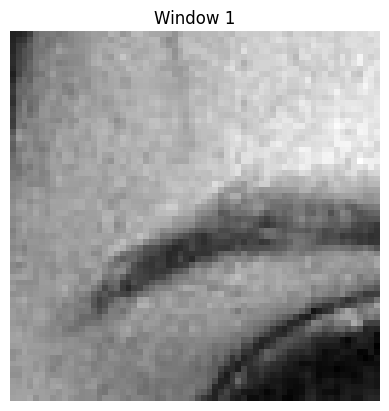

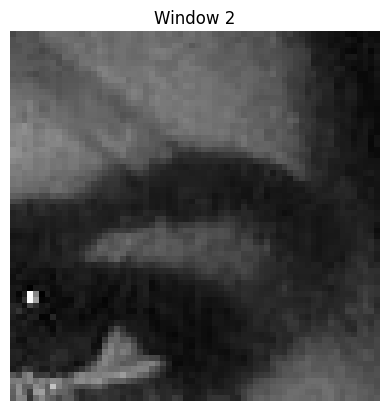

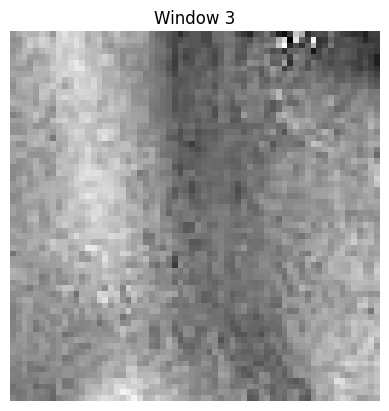

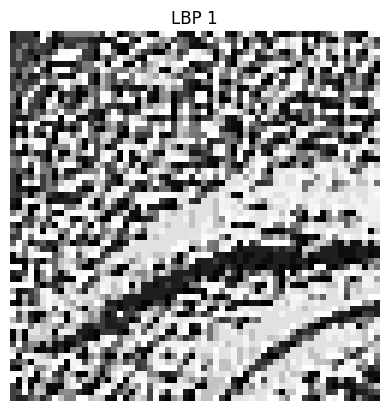

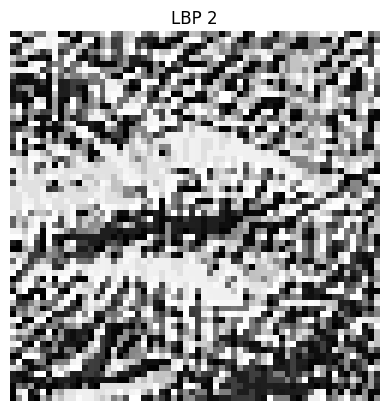

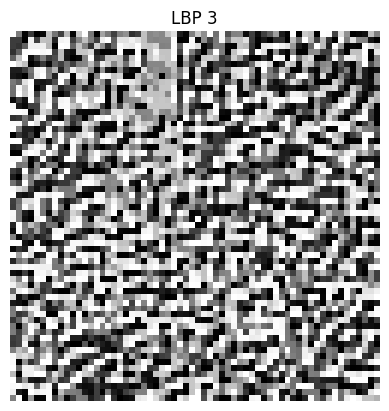

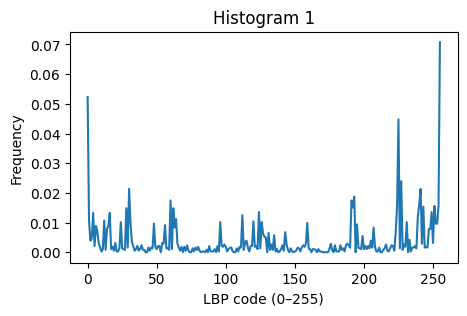

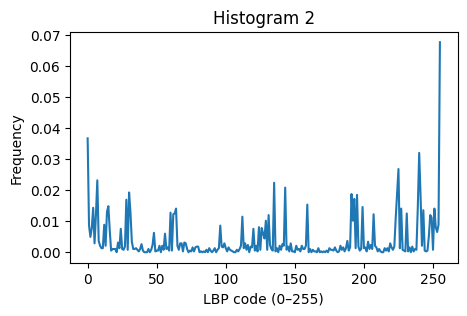

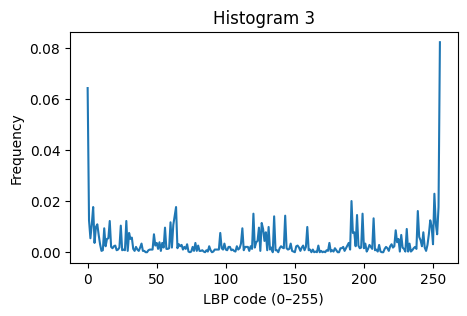

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Save everything in outputs/
os.makedirs("outputs", exist_ok=True)

# --- Load grayscale image from Dataset A ---
img = cv2.imread("DatasetA/face-3.jpg", cv2.IMREAD_GRAYSCALE)

print("Loaded:", img is not None, "Shape:", None if img is None else img.shape)

# --- Function: split into windows ---
def split_windows(I, win_h, win_w):
    windows = []
    h, w = I.shape
    for y in range(0, h, win_h):
        for x in range(0, w, win_w):
            win = I[y:y+win_h, x:x+win_w]
            if win.shape == (win_h, win_w):  # ensure full window
                windows.append(win)
    return windows

# --- LBP for one window ---
def compute_lbp(win):
    h, w = win.shape
    lbp = np.zeros((h-2, w-2), dtype=np.uint8)

    for y in range(1, h-1):
        for x in range(1, w-1):
            center = win[y, x]
            code = 0
            code |= (win[y-1, x-1] >= center) << 7
            code |= (win[y-1, x  ] >= center) << 6
            code |= (win[y-1, x+1] >= center) << 5
            code |= (win[y,   x+1] >= center) << 4
            code |= (win[y+1, x+1] >= center) << 3
            code |= (win[y+1, x  ] >= center) << 2
            code |= (win[y+1, x-1] >= center) << 1
            code |= (win[y,   x-1] >= center)
            lbp[y-1, x-1] = code

    return lbp

# --- Create 64x64 windows ---
win_h, win_w = 64, 64
windows = split_windows(img, win_h, win_w)

# Pick 3 non-consecutive windows
w1, w2, w3 = windows[0], windows[3], windows[6]

# Save windows
for i, w in enumerate([w1, w2, w3], start=1):
    plt.imshow(w, cmap="gray")
    plt.axis("off")
    plt.title(f"Window {i}")
    plt.savefig(f"outputs/4_window_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Compute LBPs
lbps = [compute_lbp(w) for w in [w1, w2, w3]]

# Save LBPs
for i, lbp in enumerate(lbps, start=1):
    plt.imshow(lbp, cmap="gray")
    plt.axis("off")
    plt.title(f"LBP {i}")
    plt.savefig(f"outputs/4_lbp_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Compute histograms
for i, lbp in enumerate(lbps, start=1):
    hist, _ = np.histogram(lbp.flatten(), bins=256, range=(0, 256), density=True)
    
    plt.figure(figsize=(5,3))
    plt.plot(hist)
    plt.title(f"Histogram {i}")
    plt.xlabel("LBP code (0–255)")
    plt.ylabel("Frequency")
    plt.savefig(f"outputs/4_hist_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()

True labels:       ['car', 'car', 'car', 'face', 'face', 'face']
Predicted labels:  ['car', 'car', 'car', 'face', 'face', 'face']


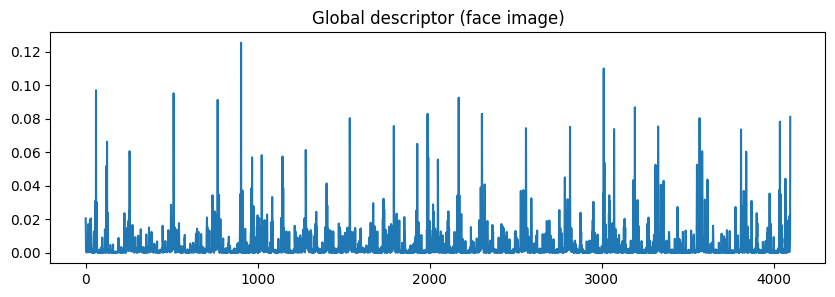

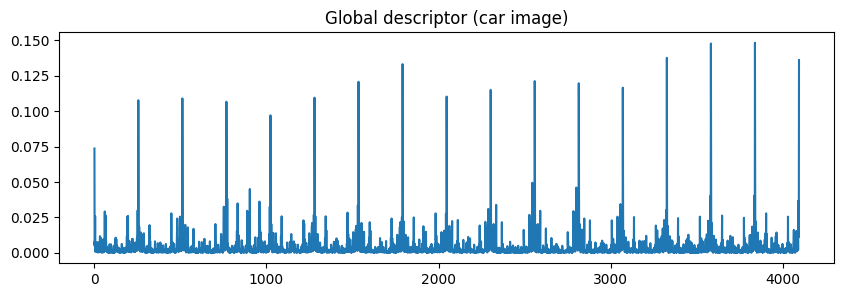

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Make sure outputs folder exists
os.makedirs("outputs", exist_ok=True)

# ------------------------
# Helper: compute LBP (same as before)
# ------------------------
def compute_lbp(win):
    h, w = win.shape
    lbp = np.zeros((h-2, w-2), dtype=np.uint8)

    for y in range(1, h-1):
        for x in range(1, w-1):
            c = win[y, x]
            code = 0
            code |= (win[y-1, x-1] >= c) << 7
            code |= (win[y-1, x  ] >= c) << 6
            code |= (win[y-1, x+1] >= c) << 5
            code |= (win[y,   x+1] >= c) << 4
            code |= (win[y+1, x+1] >= c) << 3
            code |= (win[y+1, x  ] >= c) << 2
            code |= (win[y+1, x-1] >= c) << 1
            code |= (win[y,   x-1] >= c)
            lbp[y-1, x-1] = code

    return lbp

# ------------------------
# Split into windows
# ------------------------
def split_windows(I, win_h=64, win_w=64):
    windows = []
    h, w = I.shape
    for y in range(0, h, win_h):
        for x in range(0, w, win_w):
            win = I[y:y+win_h, x:x+win_w]
            if win.shape == (win_h, win_w):
                windows.append(win)
    return windows

# ------------------------
# Compute descriptor: concatenate histograms of windows
# ------------------------
def global_descriptor(img):
    windows = split_windows(img)
    desc_parts = []

    for w in windows:
        lbp = compute_lbp(w)
        hist, _ = np.histogram(lbp.flatten(), bins=256, range=(0,256), density=True)
        desc_parts.append(hist)

    return np.concatenate(desc_parts)   # final descriptor vector

# ------------------------
# Histogram intersection similarity
# ------------------------
def hist_intersection(h1, h2):
    return np.sum(np.minimum(h1, h2))

# ------------------------
# Load Dataset A images
# ------------------------
image_files = [
    "DatasetA/car-1.jpg",
    "DatasetA/car-2.jpg",
    "DatasetA/car-3.jpg",
    "DatasetA/face-1.jpg",
    "DatasetA/face-2.jpg",
    "DatasetA/face-3.jpg"
]

labels = ["car", "car", "car", "face", "face", "face"]

images = []
descriptors = []

for f in image_files:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    images.append(img)
    descriptors.append(global_descriptor(img))

# ------------------------
# Classification:
# Compare each image to each other image and predict class
# ------------------------
predictions = []

for i in range(len(descriptors)):
    sims = []
    for j in range(len(descriptors)):
        if i != j:
            sims.append((hist_intersection(descriptors[i], descriptors[j]), labels[j]))

    # pick the label of the most similar image
    best_match = max(sims, key=lambda x: x[0])[1]
    predictions.append(best_match)

# Print classification results
print("True labels:      ", labels)
print("Predicted labels: ", predictions)

# ------------------------
# Save one FACE and one CAR descriptor plot (for the report template)
# ------------------------
face_desc = descriptors[4]   # face-2.jpg descriptor
car_desc = descriptors[1]    # car-2.jpg descriptor
# ------------------------
# Show the two images used for descriptors
# ------------------------

# ------------------------
# Load Dataset A images (both color + grayscale)
# ------------------------
images_color = []
images_gray = []
descriptors = []

for f in image_files:
    img_color = cv2.imread(f)  # COLOR (for showing in report)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)  # GRAYSCALE (for LBP)

    images_color.append(img_color)
    images_gray.append(img_gray)

    descriptors.append(global_descriptor(img_gray))  # descriptor uses grayscale only

plt.figure(figsize=(10,3))
plt.plot(face_desc)
plt.title("Global descriptor (face image)")
plt.savefig("outputs/4_face_descriptor.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(car_desc)
plt.title("Global descriptor (car image)")
plt.savefig("outputs/4_car_descriptor.png", dpi=300, bbox_inches="tight")
plt.show()


--- Window size: 32x32 ---


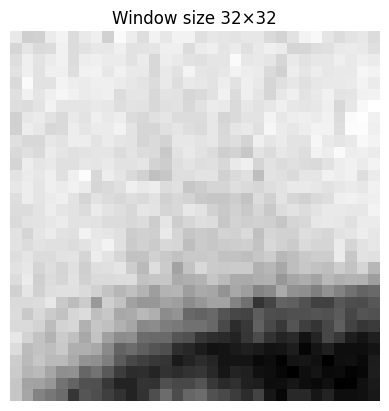

True:       ['car', 'car', 'car', 'face', 'face', 'face']
Predicted:  ['car', 'car', 'car', 'face', 'face', 'face']

--- Window size: 64x64 ---


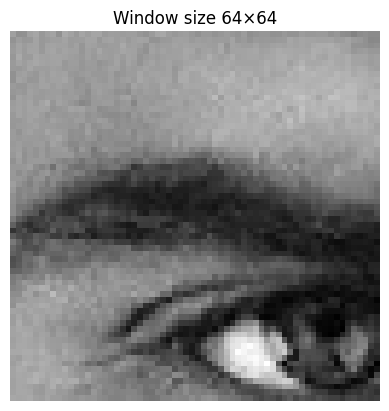

True:       ['car', 'car', 'car', 'face', 'face', 'face']
Predicted:  ['car', 'car', 'car', 'face', 'face', 'face']

--- Window size: 128x128 ---


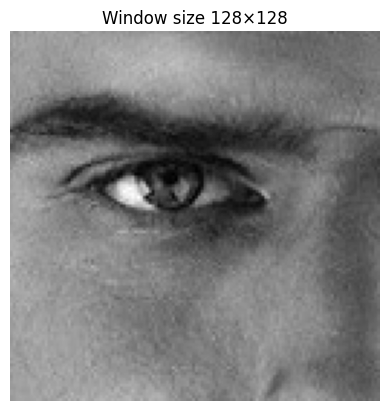

True:       ['car', 'car', 'car', 'face', 'face', 'face']
Predicted:  ['car', 'car', 'car', 'face', 'face', 'face']


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

# ------------------------
# Reuse LBP function
# ------------------------
def compute_lbp(win):
    h, w = win.shape
    lbp = np.zeros((h-2, w-2), dtype=np.uint8)

    for y in range(1, h-1):
        for x in range(1, w-1):
            c = win[y, x]
            code = 0
            code |= (win[y-1, x-1] >= c) << 7
            code |= (win[y-1, x  ] >= c) << 6
            code |= (win[y-1, x+1] >= c) << 5
            code |= (win[y,   x+1] >= c) << 4
            code |= (win[y+1, x+1] >= c) << 3
            code |= (win[y+1, x  ] >= c) << 2
            code |= (win[y+1, x-1] >= c) << 1
            code |= (win[y,   x-1] >= c)

            lbp[y-1, x-1] = code

    return lbp

# ------------------------
# Split image into windows
# ------------------------
def split_windows(I, win_h, win_w):
    windows = []
    h, w = I.shape
    for y in range(0, h, win_h):
        for x in range(0, w, win_w):
            win = I[y:y+win_h, x:x+win_w]
            if win.shape == (win_h, win_w):
                windows.append(win)
    return windows

# ------------------------
# Global descriptor
# ------------------------
def global_descriptor(img, win_size):
    windows = split_windows(img, win_size, win_size)
    desc_parts = []

    for w in windows:
        lbp = compute_lbp(w)
        hist, _ = np.histogram(lbp.flatten(), bins=256, range=(0, 256), density=True)
        desc_parts.append(hist)

    return np.concatenate(desc_parts), windows

# ------------------------
# Histogram intersection
# ------------------------
def hist_intersection(h1, h2):
    return np.sum(np.minimum(h1, h2))

# ------------------------
# Load Dataset A images
# ------------------------
image_files = [
    "DatasetA/car-1.jpg",
    "DatasetA/car-2.jpg",
    "DatasetA/car-3.jpg",
    "DatasetA/face-1.jpg",
    "DatasetA/face-2.jpg",
    "DatasetA/face-3.jpg"
]

labels = ["car", "car", "car", "face", "face", "face"]

images = [cv2.imread(f, cv2.IMREAD_GRAYSCALE) for f in image_files]

# ------------------------
# Test window sizes
# ------------------------
window_sizes = [32, 64, 128]

for S in window_sizes:
    print(f"\n--- Window size: {S}x{S} ---")

    # Compute descriptors
    descs = []
    all_windows = []

    for img in images:
        d, wins = global_descriptor(img, S)
        descs.append(d)
        all_windows.append(wins)

    # ---------------------
    # Save ONE sample window
    # ---------------------
    sample = all_windows[3][0]
    plt.imshow(sample, cmap="gray")
    plt.title(f"Window size {S}×{S}")
    plt.axis("off")
    plt.savefig(f"outputs/4c_window_{S}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---------------------
    # Compute similarity matrix
    # ---------------------
    n = len(descs)
    sim = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            sim[i, j] = hist_intersection(descs[i], descs[j])

    # Save numerical evidence
    np.save(f"outputs/4c_similarity_{S}.npy", sim)

    # ---------------------
    # Perform classification
    # ---------------------
    predictions = []

    for i in range(n):
        best = -1e9
        best_label = None
        for j in range(n):
            if i == j:
                continue
            if sim[i,j] > best:
                best = sim[i,j]
                best_label = labels[j]
        predictions.append(best_label)

    # Save predictions
    with open(f"outputs/4c_predictions_{S}.txt", "w") as f:
        f.write("True labels:      " + str(labels) + "\n")
        f.write("Predicted labels: " + str(predictions) + "\n")
        f.write("Similarity matrix saved as 4c_similarity_%d.npy\n" % S)

    print("True:      ", labels)
    print("Predicted: ", predictions)